 ## Note
 **Kernel SVMの考え方:**
 - 1. 非線形データに対応するため写像$\phi$を用いて、$w \cdot \phi(x_i) + b$で分類を行いたい
 - 2. $\phi$は無限次元への写像であり計算はできないが、SVMの目的関数からカーネルトリックにより、$$K(x, x') = \phi(x) \cdot \phi(x')$$ と特徴空間での内積を、カーネル関数の計算に置き換える
 - 3. $K(x, x')$としてもデータの組み合わせに対しての計算量が大きいため近似を行う

 **Random Fourier Featuresによる近似:** <br/>
 カーネルをフーリエ変換し、サンプリングにより近似する
 1. 周波数$\omega_i$を以下でサンプリング
     $$ \omega_i \sim N(0, 2\gamma I)$$
 2. 特徴量の変換を以下で行う
     $$ \phi_{\omega_i}(x) = [cos(\omega_i \cdot x), sin(\omega_i \cdot x)] $$
 3. 変換後の特徴ベクトルを以下とする($D$はサンプル周波数の数)
     $$ z(x) = \frac{1}{\sqrt{D}}[\phi_{\omega_1}(x), \phi_{\omega_2}(x), ..., \phi_{\omega_D}(x)] $$
 この$z(x)$について
 $$ K(x, x') =\phi(x) \cdot \phi(x') \approx z(x) \cdot z(x')$$

In [ ]:
import numpy as np
from IPython.display import display
from numpy.typing import NDArray
from sklearn.datasets import make_moons
from step4_perceptron import History, LogItem, TrainLogAnimation
from step5_linear_svm import LinearSupportVectorMachine

rng = np.random.default_rng(seed=123)


def init_moons_dataset(
    cluster_std: float = 0.05,
    n_samples: int = 300,
) -> tuple[NDArray, NDArray]:
    X, y = make_moons(
        n_samples=n_samples,
        noise=cluster_std,
        random_state=123,
    )

    y = np.where(y == 0, 1, -1)

    return X, y

In [ ]:
class RandomFourierFeatures:
    def __init__(self, input_features: int = 2, gamma: float = 5.0, D: int = 3000):
        self.D = D
        self.omega = rng.normal(
            loc=0.0,
            scale=np.sqrt(2 * gamma),
            size=(D, input_features),
        )

    def transform(self, X: NDArray) -> NDArray:
        dot_product = X @ self.omega.T
        z1 = np.cos(dot_product)
        z2 = np.sin(dot_product)
        z = np.concat([z1, z2], axis=-1) / np.sqrt(self.D)
        return z


class KernelSupportVectorMachine(LinearSupportVectorMachine):
    def __init__(
        self,
        ndim: int = 2,
        gamma: float = 4.5,
        D: int = 3000,
        eta: float = 0.0003,
        C: float = 5,
        tolerance: float = 0.01,
        patience: int = 10,
    ):
        super().__init__(ndim=D * 2, eta=eta)
        self.C = C
        self.rff = RandomFourierFeatures(input_features=ndim, gamma=gamma, D=D)
        self.D = D
        self.tolerance = tolerance
        self.patience = patience
        self._convergence_count = 0

    def train(self, Dx: NDArray, Dy: NDArray, epochs: int = 100) -> History:
        history = History(Dx, Dy, epochs)
        history.append(LogItem(self.copy()))

        Dz = self.rff.transform(Dx)

        for i in range(epochs):
            w_old = self.w[:]
            b_old = self.b
            for x_i, y_i, z_i in zip(Dx, Dy, Dz):
                history.append(LogItem(self.copy(), x_i, y_i))
                self.w, self.b = self._train_step(z_i, y_i)

            delta = self._calculate_delta(w_old, b_old)
            print(f"epoch {i + 1}: {delta = }")
            if self._is_converged(delta):
                break
        return history

    def score(self, X: NDArray) -> NDArray:
        if X.shape[-1] != 2 * self.D:
            X = self.rff.transform(X)
        return super().score(X)

epoch 1: delta = np.float64(6.818453387698702)
epoch 2: delta = np.float64(6.236966383035004)
epoch 3: delta = np.float64(5.689962963030883)
epoch 4: delta = np.float64(5.195571631377464)
epoch 5: delta = np.float64(4.739456702663377)
epoch 6: delta = np.float64(4.328494374220627)
epoch 7: delta = np.float64(3.952002840199834)
epoch 8: delta = np.float64(3.604028164310435)
epoch 9: delta = np.float64(3.2908215829563927)
epoch 10: delta = np.float64(3.006903192161515)
epoch 11: delta = np.float64(2.7455275026918162)
epoch 12: delta = np.float64(2.509124598896238)
epoch 13: delta = np.float64(2.2807810049118724)
epoch 14: delta = np.float64(2.0828652454705905)
epoch 15: delta = np.float64(1.9017301946610399)
epoch 16: delta = np.float64(1.73291068003217)
epoch 17: delta = np.float64(1.5826279526992324)
epoch 18: delta = np.float64(1.4451377310301152)
epoch 19: delta = np.float64(1.3208677274749412)
epoch 20: delta = np.float64(1.2072804038783083)
epoch 21: delta = np.float64(1.1034854338

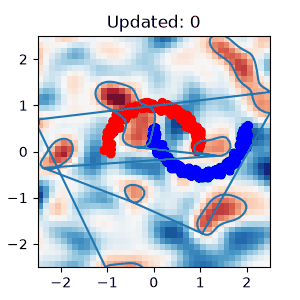

In [ ]:
def main():
    Dx, Dy = init_moons_dataset()

    model = KernelSupportVectorMachine()
    history = model.train(Dx, Dy)
    output_frames = 150
    frame_sampling_rate = min(1.0, output_frames / len(history))

    log_anim = TrainLogAnimation(
        history,
        xlim=(-2.5, 2.5),
        ylim=(-2.5, 2.5),
    )
    display(
        log_anim.plot(
            figsize=(3, 3), frame_sampling_rate=frame_sampling_rate, update=False
        )
    )


if __name__ == "__main__":
    main()